# BEE 4750 Homework 2: Systems Modeling and Simulation

**Name**: David Rha and Evan Sims

**ID**: _________ and 5359764

> **Due Date**
>
> Thursday, 09/25/25, 9:00pm

## Overview

### Instructions

-   Problem 1 asks you to draw a systems diagram and identify the type
    of a feedback.
-   Problem 2 asks you to model contaminant concentrations in a river
    and use simulation to compare the concentrations to a regulatory
    standard.
-   Problem 3 asks you to explore the implications of an ice-albedo
    feedback in the Earth’s climate system by understanding the
    equilibria of the modeled system and their stabilities.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [ ]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

using Plots
using LaTeXStrings
using CSV
using DataFrames
using Roots

  Activating project at `~/Documents/School/Senior/BEE 4750/hw2-rha-sims`
   Installed WorkerUtilities ───────────── v1.6.1
   Installed JpegTurbo_jll ─────────────── v3.1.3+0
   Installed SentinelArrays ────────────── v1.4.8
   Installed InlineStrings ─────────────── v1.4.5
   Installed InvertedIndices ───────────── v1.3.1
   Installed Accessors ─────────────────── v0.1.42
   Installed Roots ─────────────────────── v2.2.10
   Installed DataFrames ────────────────── v1.8.0
   Installed WeakRefStrings ────────────── v1.4.2
   Installed Ghostscript_jll ───────────── v9.55.1+0
   Installed PooledArrays ──────────────── v1.4.3
   Installed TableTraits ───────────────── v1.0.1
   Installed ConstructionBase ──────────── v1.6.0
   Installed DataValueInterfaces ───────── v1.0.0
   Installed CompositionsBase ──────────── v0.1.2
   Installed CommonSolve ───────────────── v0.2.4
   Installed PrettyTables ──────────────── v3.0.8
   Installed Crayons ───────────────────── v4.1.1
   Installed Invers

In [3]:
using Plots
using LaTeXStrings
using CSV
using DataFrames
using Roots

## Problems (Total: 30 Points)

### Problem 1 (5 points)

Draw a systems diagram for the relationship between global mean
temperature, atmospheric CO<sub>2</sub> concentrations, and ocean
CO<sub>2</sub> concentrations. What are the signs of the interactions
between these components and why? What does this suggest about the
overall feedback between temperature and the ocean carbon cycle?

> **Tip**
>
> Think about Henry’s law for CO<sub>2</sub>.

### Problem 2 (15 points)

A river which flows at 10 km/d is receiving discharges of wastewater
contaminated with CRUD from two sources which are 15 km apart, as shown
in the Figure below. CRUD decays exponentially in the river at a rate of
0.36 $\mathrm{d}^{-1}$ and is deposited by the atmosphere along the
river at a rate of 54 kg/km/d. 

<figure>
<img src="attachment:figures/river_diagram.png"
alt="Schematic of the river system in Problem 2" />
<figcaption aria-hidden="true">Schematic of the river system in Problem
2</figcaption>
</figure>

#### Problem 2.1

Draw a systems diagram with the relevant control volume(s) denoted and
any relevant in/out-flows between these boxes. How did you decide how
many boxes were needed?

#### Problem 2.2

Develop a model for the concentration of CRUD downriver by formulating
and solving the appropriate differential equation(s) analytically.

#### Problem 2.3

Determine if the system in compliance with a regulatory limit of
$2.3\ \text{kg}/(1000 \text{m}^3)$. You can do this analytically or
computationally.

> **Tip**
>
> Formulate your model in terms of distance downriver, rather than
> leaving it in terms of time from discharge.

#### Box 1 & 3

$ Q_o = Q_i + Q_d $

$ C_o = \frac{Q_iC_i + Q_dC_d}{Q_o} $



#### Box 2 & 4
$ D =$ deposition rate (kg/km/d)

$ k =$ decay rate (1/d)

$ \frac{dC}{dt} = D*v_{river}/Q_{river} - k*C $ --> units of kg/m^3/d

$ \frac{dt}{dx} = 1/v_{river} $ using this relationship will convert dC/dt to dC/dx

$ \frac{dC}{dx} = \frac{1}{v_{river}}[D*v_{river}/Q_{river} - k*C] = D/Q_{river} + k*v_{river}*C$

$ \frac{C(x+\Delta x) - C(x)}{\Delta x} = D/Q_{river} - k*v_{river}*C(x) $

$ C(x+\Delta x) = [\Delta x*(D/Q_{river} - k*v_{river}*C(x))] + C(x) $





[0.0017984137931034484, 0.0019198777931034483, 0.002036969089103448, 0.002149845098447448, 0.002258657571455064, 0.002363552795434406, 0.0024646717913504915, 0.002562150503413598, 0.0026561199818424326, 0.002746706559047829, 0.0028340320194738316, 0.002918213763324498, 0.00299936496439654, 0.003077594722229989, 0.0031530082087814332][0.0038295284995626786, 0.0038459511878641364, 0.0038617826593867416, 0.0038770441979345334, 0.0038917563210946046, 0.003905938807820913, 0.003919610725025074, 0.003932790453209886, 0.003945495711180044, 0.003957743579863277, 0.003969550525273913, 0.003980932420649767, 0.0039919045677920895, 0.004002481717637289, 0.004012678090088061]

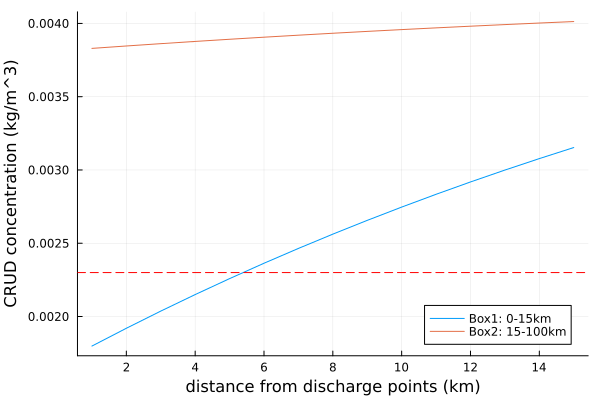

In [ ]:
# Model parameters given in the problem statement
velo = 10 #km/d
delta = 1 #km
steps_1 = 15 #km
steps_2 = 15 #km
Qo1 = 250000 #m^3/d
Co1 = 0.5 / 1000 #kg/m^3, the 1000 corrects for the units given being in kg/(1000*m^3) but I set up the equation expecting kg/m^3
Qd1 = 40000 #m^3/d
Cd1 = 9 / 1000 #kg/m^3, the 1000 corrects for the units given being in kg/(1000*m^3) but I set up the equation expecting kg/m^3
Qd2 = 60000 #m^3/d
Cd2 = 7 / 1000 #kg/m^3, the 1000 corrects for the units given being in kg/(1000*m^3) but I set up the equation expecting kg/m^3
decay = 0.36 #d^-1
deposition = 54 #kg/km/d

# Model function definitions; model separated into 2 types of boxes: box_1 for immediate discharge mixing in an infinitesimally small
# length of the river, and box_2 to cover change in concentration for the rest of the river area accounting for deposition and decay.
function box_1(Qo,Co,Qd,Cd)
    #initial conditions
    Qi = Qo + Qd #m^3/d
    Ci = (Qo*Co + Qd*Cd)/Qi #kg/m^3
    return (Qi, Ci)
end
length
function box_2(Qi,Ci,velo,decay,deposition,steps,delta)
    f_x = zeros(steps)
    C = Ci
    for i in 1:steps
        C_next = delta * (deposition/Qi - decay/velo*C) + C
        C = C_next
        f_x[i] = C
    end
    return (C, f_x)
end

# Defining the function to combine these two box types in the way presented in the problem, covering the river with
# 4 total boxes, two of each type. It will return arrays with the concentration at every delta
function total_concentration(Qo1,Co1,Qd1,Cd1,Qd2,Cd2,velo,decay,deposition,steps_1,steps_2,delta)
    Qi1, Ci1 = box_1(Qo1,Co1,Qd1,Cd1)
    C2, f_x1 = box_2(Qi1,Ci1,velo,decay,deposition,steps_1,delta)

    Qi3, Ci3 = box_1(Qi1,C2,Qd2,Cd2)
    C3, f_x2 = box_2(Qi3,Ci3,velo,decay,deposition,steps_2,delta)
    return (f_x1, f_x2)
end


box2, box4 = total_concentration(Qo1,Co1,Qd1,Cd1,Qd2,Cd2,velo,decay,deposition,steps_1,steps_2,delta)
print(box2,box4)
plot(1:steps_1,box2, label="Box1: 0-15km")
plot!(1:steps_2,box4, label="Box2: 15-100km")
ylabel!("CRUD concentration (kg/m^3)")
xlabel!("distance from discharge points (km)")
hline!([2.3/1000], color=:red, linestyle=:dash, label="")

### Problem 3 (10 points)

In class, we discussed the ice-albedo feedback and its possible
influence on melting the hypothesized [“Snowball
Earth”](https://en.wikipedia.org/wiki/Snowball_Earth). In this problem,
we’ll introduce a simple model of the Earth’s energy balance with
includes this feedback and examine the stability of the climate.

This simple model of the energy balance (averaged over the entire
planet) is:

<span id="eq-climate">$$
\underbrace{C\frac{dT}{dt}}_{\text{change in heat}} = \underbrace{\frac{(1-\alpha)S}{4}}_{\text{incoming radiation}} - \underbrace{(A - BT)}_{\text{outgoing radiation}} + \underbrace{a\ln \left(\frac{[CO_2]}{[CO_2]_{PI}}\right)}_{\text{greenhouse effect}},
 \qquad(1)$$</span>

where:

-   $T$ is the Earth’s global mean temperature (in $^\circ\text{C}$);
-   $C$ is the heat capacity of the atmosphere and shallow ocean, taken
    to be $51\ \text{J}/\text{m}^2/^\circ\text{C}$;
-   $\alpha$ is the planetary albedo, or the fraction of incoming
    radiation reflected by the Earth, which has a present-day value of
    approximately 0.3;
-   $S$ is the solar constant, or the amount of solar radiation received
    by the Earth averaged over area, which has a present-day value of
    $1368\ \text{W}/\text{m}^2$ but during the Neoproteorozoic Era had a
    value of $1272\ \text{W}/\text{m}^2$ (this is divided by four
    because the Earth is a sphere but $S$ is the radiation captured by a
    disc with radius equal to that of the Earth);
-   $A$ and $B$ are coefficients from the linearization of outgoing
    radiation physics, and have corresponding values
    $B=-1.3\ \text{W}/\text{m}^2/^\circ\text{C}$ (estimated from a
    number of lines of evidence about the sensitivity of outgoing
    radiation to temperature; this is negative due to a sign convention
    about the direction of incoming vs. outgoing radiation) and
    $A=221.2\ \text{W}/\text{m}^2$ (estimated by assuming the
    pre-industrial temperature of $14^\circ\text{C}$ was stable without
    anthropogenic greenhouse gas emissions).

We will ignore the greenhouse effect term as we are considering the
Earth system well before humans were around.

#### Problem 3.1

Discretize the climate model
(<a href="#eq-climate" class="quarto-xref">Equation 1</a>) using forward
Euler integration and a time step of $\Delta t = 1$ yr.

$C\frac{T(t+\Delta t)-T(t)}{\Delta t} = \frac{(1-\alpha)S}{4} - (A-B*T(t)) + a\ln(\frac{[CO_2]}{[CO_2]_{PI}})$

With a $ \Delta t = $ 1 year, this becomes:

$C(T(t+1)-T(t))= \frac{(1-\alpha)S}{4} - (A-B*T(t)) + a\ln(\frac{[CO_2]}{[CO_2]_{PI}})$

Solving for T(t+1):

$T(t+1) = \frac{1}{C}[\frac{(1-\alpha)S}{4} - (A-B*T(t)) + a\ln(\frac{[CO_2]}{[CO_2]_{PI}})] + T(t)$

If we are ignoring the greenhouse effect for a pre-human Earth system:

$T(t+1) = \frac{1}{C}[\frac{(1-\alpha)S}{4} - (A-B*T(t))] + T(t)$

 


#### Problem 3.2

Rather than assuming a constant value for the albedo $\alpha$, we will
represent the ice-albedo feedback by letting $\alpha$ depend on $T$:

$$\alpha(T) = 
    \begin{cases} 
        \alpha_i & \quad \text{if } T \leq -10^\circ \text{C} \\
        \alpha_i + (\alpha_0 - \alpha_i)((T+10) / 20) & \quad \text{if } -10^\circ \text{C} \leq T \leq 10^\circ \text{C} \\
        \alpha_0 & \quad \text{if } T \geq 10^\circ \text{C}.
    \end{cases}$$

Let $\alpha_i = 0.5$ and $\alpha_0 = 0.3$. Simulate the simple climate
model using the Neoprotereozoic value of $S$ with temperature-varying
albedo for initial values of $T$ spanning
$-60^\circ\text{C} \leq T_0 \leq 30^\circ\text{C}$ over a period of 200
years. Plot the temperature trajectories. How many equilibria are there
and what are their stabilities?

New equation with $\alpha$ being temperature dependent:

$T(t+1) = \frac{1}{C}[\frac{(1-\alpha(T))S}{4} - (A-B*T(t))] + T(t)$

Inputing known values:

$T(t+1) = \frac{1}{51}[\frac{(1-\alpha(T))*1272}{4} - (221.2-1.3*T(t))] + T(t)$


In [17]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()
Pkg.add("Plots")
using Plots


  Activating project at `~/Documents/School/Senior/BEE 4750/hw2-rha-sims`
   Resolving package versions...
  No Changes to `~/Documents/School/Senior/BEE 4750/hw2-rha-sims/Project.toml`
  No Changes to `~/Documents/School/Senior/BEE 4750/hw2-rha-sims/Manifest.toml`


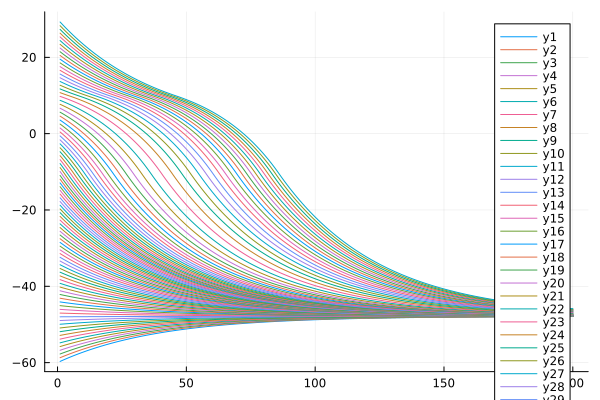

In [ ]:
#create a function for the albedo depending on the temperature
function alpha(T,ai,ao)
    if T>=10.0
        return ao 
    end
    if T<=-10.0
        return ai
    end
    return ai+(ao-ai)*((T+10)/20)
end

#create a function for the next temperature in the forward Euler discretization of the earth system
function Tnext(To,C,S,A,B,ai,ao)
    T_1 = (1/C)*((1-alpha(To,ai,ao))*S/4 - (A-B*To)) + To
    return T_1
end


#Assign values given to each in the problem statement
ai = 0.5
ao = 0.3
C = 51 #J/m^2/degC
S = 1272 #W/m^2
A = 221.2 #W/m^2
B = -1.3 #W/m^2/degC

T_values = LinRange(-60,30,91)
all_T = zeros(91,200)

for i in 1:91
    T = T_values[i]
    for j in 1:200
        t_1 = Tnext(T,C,S,A,B,ai,ao)
        T = t_1
        all_T[i,j] = T
    end
end

plot(all_T')

I used ChatGPT to help me find a bug when trying to compile my vectors that contained each trajectory and sort out the best way of compiling the trajectories from each intitial T value. I had initially tried to add vectors that stored every T value in a 200 year trajectory and then add that to the original trajectories vector, but Julia wasn't happy with me trying to add a full vector into a scalar spot of that overall trajectory vector. It helped explain this as the source of my bug, and recommended that I create a single matrix to store values instead of combining separate vectors from each trajectory.


### Here was the exact interaction and prompts with ChatGPT:

#### Me:
Help me debug this code in Julia: 

MethodError: Cannot convert an object of type Vector{Float64} to an object of type Float64 The function convert exists, but no method is defined for this combination of argument types. Closest candidates are: convert(::Type{Float64}, !Matched::Measures.AbsoluteLength) @ Measures ~/.julia/packages/Measures/PKOxJ/src/length.jl:12 convert(::Type{T}, !Matched::T) where T<:Number @ Base number.jl:6 convert(::Type{T}, !Matched::Number) where T<:Number @ Base number.jl:7


#### ChatGPT:
This Julia error

MethodError: Cannot `convert` an object of type Vector{Float64} to an object of type Float64

means that somewhere in your code, Julia expected a single Float64 (a scalar), but you gave it a Vector{Float64} (an array of floats).

That usually happens in situations like:

Assigning an array to a variable that’s declared or initialized as a scalar.

Passing a vector where a function argument expects a number.

Doing arithmetic mixing scalars and vectors incorrectly.


#### Me:
*Provides a copy of my code*

#### ChatGPT:
Thanks for sharing the code — that clears it up!

The error comes from this line in your outer loop:

all_T[i] = T_traject


Here’s what’s happening:

all_T is a vector of length 91, with element type Float64 (zeros(91) gives you a Vector{Float64}).

T_traject is a vector of length 200.

You’re trying to store the entire vector T_traject into a single scalar slot all_T[i]. Julia says: “I can’t convert a Vector{Float64} into a Float64.” → That’s exactly the error you saw.

If you want a matrix of trajectories (rows or columns per initial condition)

Initialize as a 91×200 matrix:

all_T = zeros(91,200)

for i in 1:91
    T = T_values[i]
    for j in 1:200
        t_1 = Tnext(T,C,S,A,B,ai,ao)
        T = t_1
        all_T[i,j] = T
    end
end


Then you can plot all trajectories together with:

plot(T_values, all_T[:,end])   # final temperatures

 #or

plot(all_T')                   # plot trajectories over iterations



#### Problem 3.3

One might hypothesize that one cause for the transition from Snowball
Earth (the stable frozen equilibrium from Problem 3.2) was an increasing
amount of incoming solar radiation (as expressed by an increase in $S$).
Examine this hypothesis using our simple model. Is this factor enough to
cause the planet to warm to the pre-industrial temperature of
$14^\circ\text{C}$?

## References

Consulted with David Rha as my partner on this HW

https://discourse.julialang.org/t/float-to-int/44417
Used this source to figure out how to convert a float to an int
